# Test: Harmonic decomposition on synthetic propagating plane waves

**Goal.** Validate the per-pixel harmonic algorithm from `harmonic-cos.ipynb` against data with a *known* answer.

We build two synthetic `50 x 50 x 24` (2-year monthly) datasets containing **propagating plane waves** at a fixed angle theta:

* **(i)** annual only  (period P = 12 months)
* **(ii)** annual + biannual  (P = 12 and P = 6 months)

A plane wave `A*cos(k*(x*cos(theta) + y*sin(theta)) - omega*t)` is, at any *fixed* pixel, a pure sinusoid in time whose **phase depends on the pixel location**. So a correct per-pixel harmonic fit must recover:

* a **uniform amplitude** equal to the injected `A`, and
* a **phase that ramps linearly in space** along the propagation direction theta (the phase gradient *is* the propagation).

We also expect the **4-month harmonic amplitude to be ~0** everywhere, since no 4-month signal was injected.

No noise is added, so recovery should be essentially exact (R^2 ~ 1).

## Section A - Synthetic data generation

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---- grid definition -------------------------------------------------------
n_lat, n_lon, n_time = 50, 50, 24

# synthetic lat/lon box
lats = np.arange(n_lat, dtype=float)          # 0 .. 49
lons = np.arange(n_lon, dtype=float)          # 0 .. 49
months = pd.date_range('2003-01-01', periods=n_time, freq='MS')

t = np.arange(n_time)                          # 0 .. 23 (month index)
XX, YY = np.meshgrid(lons, lats)               # shape (n_lat, n_lon)

# ---- propagation geometry --------------------------------------------------
theta = np.deg2rad(30.0)                        # propagation angle
# spatial projection of each pixel onto the propagation direction
proj = XX * np.cos(theta) + YY * np.sin(theta)  # (n_lat, n_lon)

# choose k so ~1.5 wavelengths span the projected extent of the grid
n_wavelengths = 1
proj_span = proj.max() - proj.min()
k = 2 * np.pi * n_wavelengths / proj_span       # spatial wavenumber

print(f'grid            : {n_lat} lat x {n_lon} lon x {n_time} months')
print(f'theta           : {np.rad2deg(theta):.1f} deg')
print(f'proj span       : {proj_span:.2f}')
print(f'wavenumber k    : {k:.4f}  (~{n_wavelengths} wavelengths across grid)')

grid            : 50 lat x 50 lon x 24 months
theta           : 30.0 deg
proj span       : 66.94
wavenumber k    : 0.0939  (~1 wavelengths across grid)


In [2]:
# ---- injected (ground-truth) parameters ------------------------------------
A12 = 1.0    # annual   amplitude
A6  = 0.5    # biannual amplitude  (only used in dataset ii)

omega12 = 2 * np.pi / 12.0   # annual   angular frequency (per month)
omega6  = 2 * np.pi / 6.0    # biannual angular frequency



def plane_wave(A, omega):
    """Propagating plane wave field, shape (n_time, n_lat, n_lon).
    A*cos(k*proj - omega*t): a high-value band sweeps across the grid at angle theta."""
    tt = t[:, None, None]                        # (n_time,1,1)
    return A * np.cos(k * proj[None, :, :] - omega * tt)

# ---- dataset (i): annual only ----------------------------------------------
field_i = plane_wave(A12, omega12)

# ---- dataset (ii): annual + biannual ---------------------------------------
field_ii = plane_wave(A12, omega12) + plane_wave(A6, omega6)

coords = {'time': months, 'lat': lats, 'lon': lons}
da_i  = xr.DataArray(field_i,  dims=('time','lat','lon'), coords=coords, name='signal_annual')
da_ii = xr.DataArray(field_ii, dims=('time','lat','lon'), coords=coords, name='signal_annual_biannual')

print('dataset (i)  annual only          :', da_i.shape,  'range', float(da_i.min()),  '->', float(da_i.max()))
print('dataset (ii) annual + biannual    :', da_ii.shape, 'range', float(da_ii.min()), '->', float(da_ii.max()))
print()
print('INJECTED ground truth:')
print(f'  annual   amplitude A12 = {A12}   (uniform everywhere)')
print(f'  biannual amplitude A6  = {A6}    (dataset ii only)')
print(f'  4-month  amplitude     = 0       (should be recovered as ~0)')


dataset (i)  annual only          : (24, 50, 50) range -1.0 -> 1.0
dataset (ii) annual + biannual    : (24, 50, 50) range -1.4999988590056117 -> 1.5

INJECTED ground truth:
  annual   amplitude A12 = 1.0   (uniform everywhere)
  biannual amplitude A6  = 0.5    (dataset ii only)
  4-month  amplitude     = 0       (should be recovered as ~0)


## Section B - Animation of the propagating signals

Each frame is one month. Watch the high-value band march across the grid at 30 deg - the same high signal is handed from one set of grid cells to the next, frame by frame.

In [3]:
import os
import matplotlib.animation as animation
from IPython.display import Image, display

OUT_DIR = '../Figures'
os.makedirs(OUT_DIR, exist_ok=True)

def animate_field(da, title, fname, vmin=None, vmax=None, cmap='RdBu_r'):
    data = da.values
    if vmin is None: vmin = float(np.nanmin(data))
    if vmax is None: vmax = float(np.nanmax(data))
    fig, ax = plt.subplots(figsize=(5.5, 5))
    pcm = ax.pcolormesh(lons, lats, data[0], cmap=cmap, vmin=vmin, vmax=vmax, shading='nearest')
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04, label='signal')
    ax.set_xlabel('lon index'); ax.set_ylabel('lat index')
    ttl = ax.set_title(f'{title}\nmonth 1 / {data.shape[0]}')

    def update(i):
        pcm.set_array(data[i].ravel())
        ttl.set_text(f'{title}\nmonth {i+1} / {data.shape[0]}')
        return pcm, ttl

    anim = animation.FuncAnimation(fig, update, frames=data.shape[0], interval=250, blit=False)
    out = os.path.join(OUT_DIR, fname)
    anim.save(out, writer=animation.PillowWriter(fps=4))
    plt.close(fig)
    print('saved ->', out)
    return out

out_i  = animate_field(da_i,  'Dataset (i): annual propagating wave (theta=30 deg)',           'synthetic_annual.gif')
out_ii = animate_field(da_ii, 'Dataset (ii): annual + biannual propagating wave (theta=30 deg)','synthetic_annual_biannual.gif')

saved -> ../Figures/synthetic_annual.gif
saved -> ../Figures/synthetic_annual_biannual.gif


Dataset (i): annual only


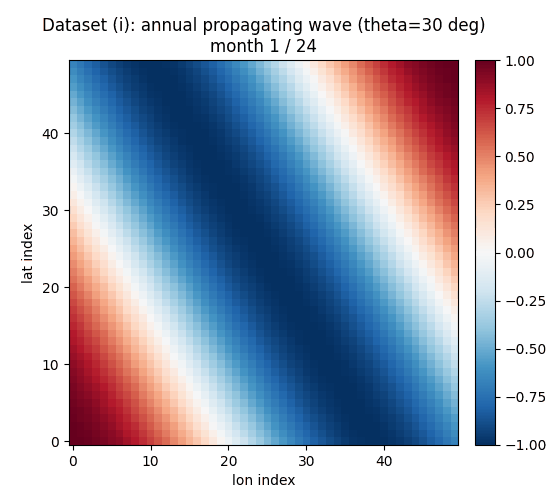

Dataset (ii): annual + biannual


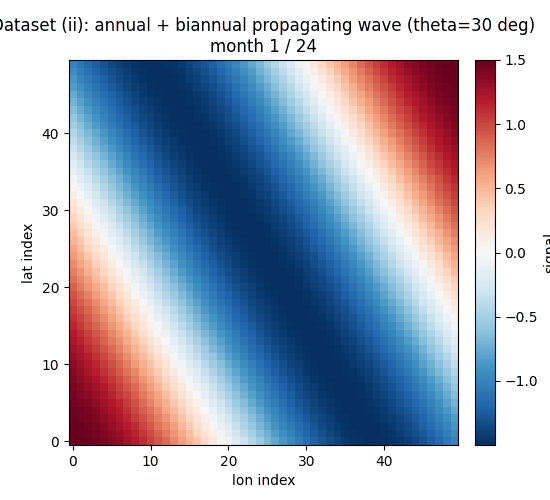

In [24]:
# display the animations inline
print('Dataset (i): annual only'); display(Image(filename=out_i))
print('Dataset (ii): annual + biannual'); display(Image(filename=out_ii))

## Section C - Harmonic decomposition (code copied from harmonic-cos.ipynb)

The block below is the harmonic-regression algorithm from `harmonic-cos.ipynb`, applied here to the synthetic field. We wrap it in a function so we can run it on both datasets. Periods are kept as `[12, 6, 4]` exactly as in the original - the 4-month harmonic is our null check.

In [4]:
periods = [12, 6, 4]

def harmonic_decompose(detr_field):
    """Per-pixel harmonic regression - identical math to harmonic-cos.ipynb."""
    months_ = pd.date_range(detr_field.time.values[0], detr_field.time.values[-1], freq='MS')
    n_lat_  = len(detr_field.lat); n_lon_ = len(detr_field.lon)

    # --- design matrix ---
    t_ = np.arange(len(months_))
    cols = []
    for P in periods:
        w = 2 * np.pi / P
        cols += [np.cos(w * t_), np.sin(w * t_)]
    M = np.column_stack(cols)                     # (n_months, 2*len(periods))

    # --- solve least squares at every pixel at once ---
    Yd = detr_field.values.reshape(len(months_), -1)
    coef, *_ = np.linalg.lstsq(M, Yd, rcond=None)

    # --- amplitude & phase in the A*cos(wt - phi) convention ---
    amp, pha = {}, {}
    for kk, P in enumerate(periods):
        a_k = coef[2*kk    ].reshape(n_lat_, n_lon_)   # cosine coeff
        b_k = coef[2*kk + 1].reshape(n_lat_, n_lon_)   # sine coeff
        amp[P] = np.sqrt(a_k**2 + b_k**2)
        pha_rad = np.arctan2(b_k, a_k)
        pha_rad = np.where(pha_rad < 0, pha_rad + 2*np.pi, pha_rad)
        pha[P] = pha_rad * (180/np.pi)
        print(f'  {P:2d}: amp {np.nanmin(amp[P]):.3e} - {np.nanmax(amp[P]):.3e}, '
              f'pha {np.nanmin(pha[P]):.2f} - {np.nanmax(pha[P]):.2f} deg')
    return M, coef, amp, pha

print('=== Dataset (i): annual only ===')
M_i,  coef_i,  amp_i,  pha_i  = harmonic_decompose(da_i)
print('\n=== Dataset (ii): annual + biannual ===')
M_ii, coef_ii, amp_ii, pha_ii = harmonic_decompose(da_ii)

=== Dataset (i): annual only ===
  12: amp 1.000e+00 - 1.000e+00, pha 2.69 - 360.00 deg
   6: amp 0.000e+00 - 7.001e-16, pha 0.00 - 357.14 deg
   4: amp 0.000e+00 - 6.004e-16, pha 0.00 - 351.87 deg

=== Dataset (ii): annual + biannual ===
  12: amp 1.000e+00 - 1.000e+00, pha 0.00 - 357.31 deg
   6: amp 5.000e-01 - 5.000e-01, pha 0.00 - 357.31 deg
   4: amp 0.000e+00 - 9.037e-16, pha 0.00 - 357.14 deg


## Section D - Amplitude / phase maps (plotting code from harmonic-cos.ipynb)

Same map layout as the original notebook. Cartopy features are guarded so the cell runs even on the synthetic (non-geographic) grid.

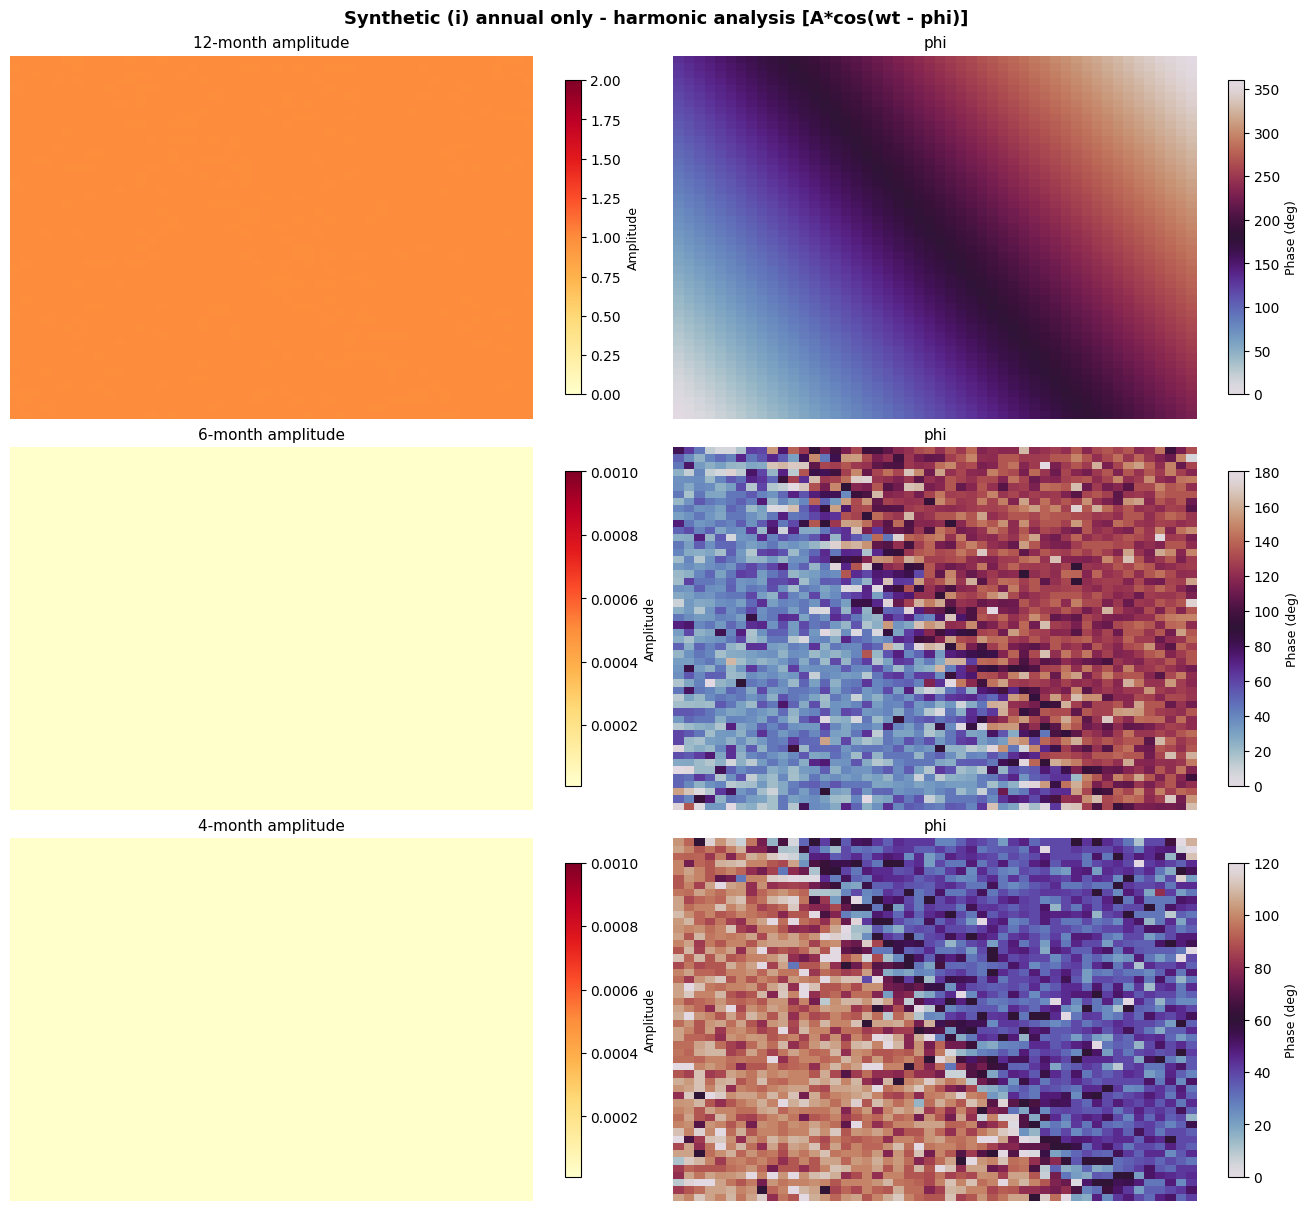

saved -> ../Figures/test_harmonics_annual.png


In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_harmonics(amp, pha, suptitle, fname):
    # Removed Cartopy projections, treating this purely as a 2D matrix plot
    fig_h, axes_h = plt.subplots(
        len(periods), 2, figsize=(13, 4*len(periods)),
        constrained_layout=True,
    )

    def harm_map(ax, data, cmap, label, title, vmin=None, vmax=None):
        pcm = ax.pcolormesh(lons, lats, data, cmap=cmap, vmin=vmin, vmax=vmax, shading='nearest')

        # Remove matrix borders and axis ticks entirely
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

        cb = fig_h.colorbar(pcm, ax=ax, orientation='vertical', fraction=0.03, pad=0.06)
        cb.set_label(label, fontsize=9)
        ax.set_title(title, fontsize=11, pad=6)

    for r, P in enumerate(periods):
        # Smart color scaling to handle flat arrays properly
        amp_data = amp[P]
        amp_min = np.nanmin(amp_data)
        amp_max = np.nanmax(amp_data)

        if amp_max < 1e-4:
            # Near-zero noise array: force a small positive scale so noise is mapped to the bottom (blank)
            c_min, c_max = 0.00001, 0.001
        else:
            # Normal varying array
            c_min, c_max = 0, 2

        harm_map(axes_h[r, 0], amp_data, 'YlOrRd', 'Amplitude',
                 f'{P}-month amplitude', vmin=c_min, vmax=c_max)

        # Scale the phase to be in reference to the first (annual) plot
        pha_scaled = pha[P] * (P / periods[0])
        pha_vmax = 360 * (P / periods[0])

        harm_map(axes_h[r, 1], pha_scaled, 'twilight', 'Phase (deg)',
                 'phi', vmin=0, vmax=pha_vmax)

    fig_h.suptitle(suptitle, fontsize=13, fontweight='bold')
    out = os.path.join(OUT_DIR, fname)
    fig_h.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    print('saved ->', out)

plot_harmonics(amp_i, pha_i,
               'Synthetic (i) annual only - harmonic analysis [A*cos(wt - phi)]',
               'test_harmonics_annual.png')


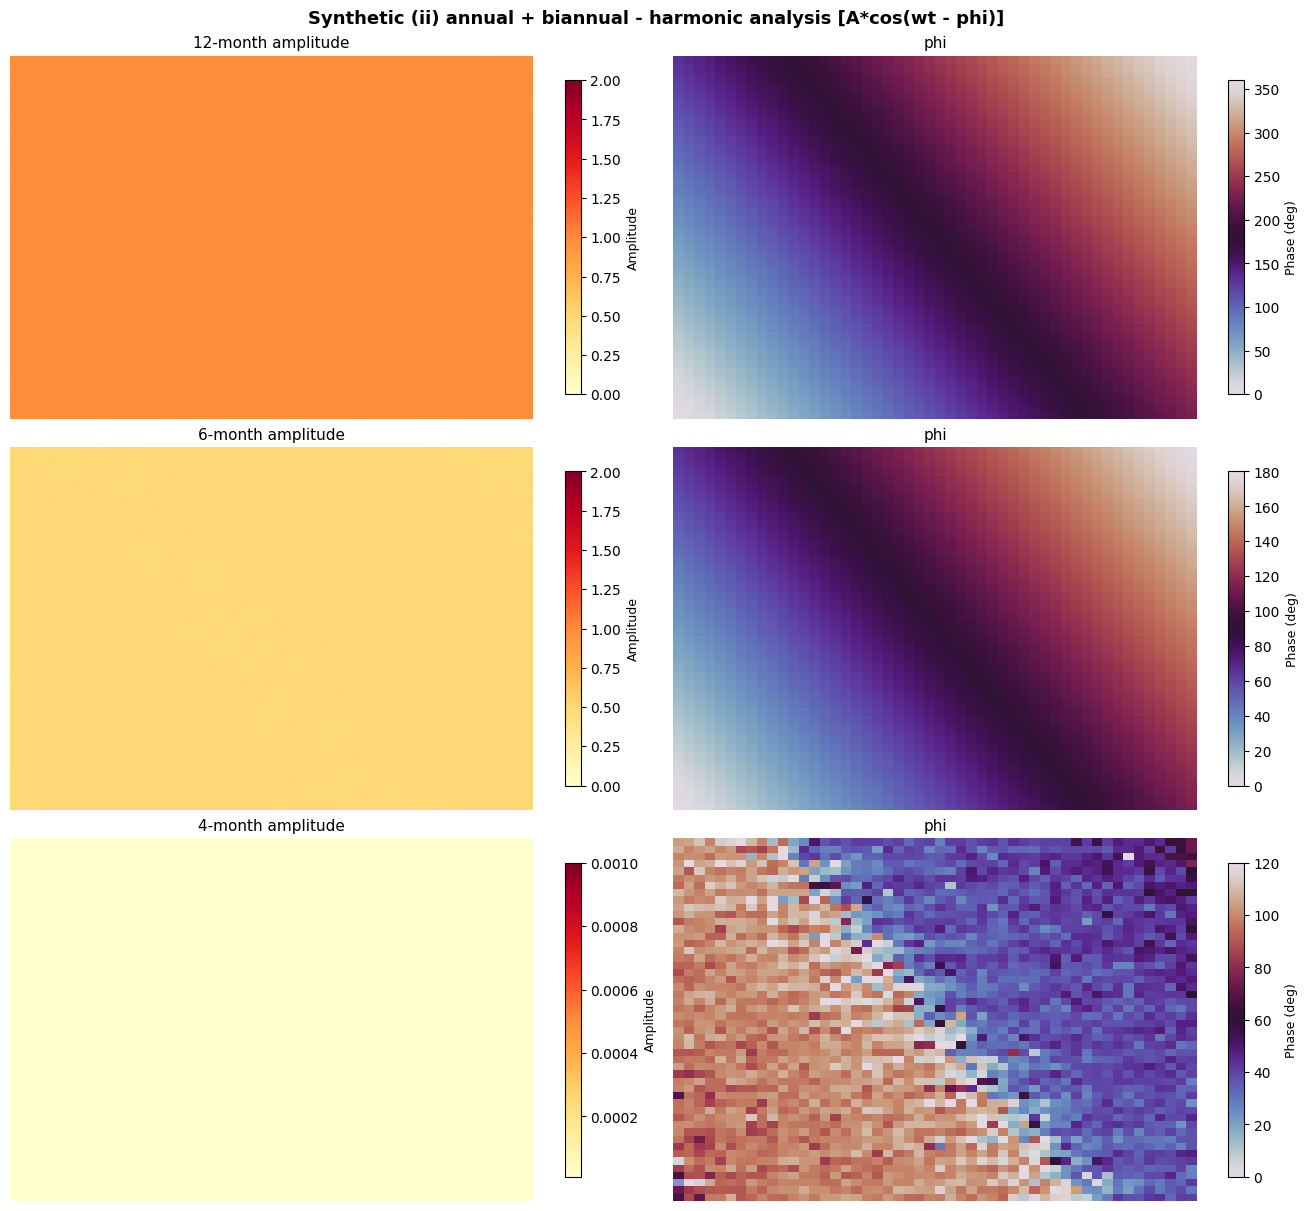

saved -> ../Figures/test_harmonics_annual_biannual.png


In [20]:
plot_harmonics(amp_ii, pha_ii,
               'Synthetic (ii) annual + biannual - harmonic analysis [A*cos(wt - phi)]',
               'test_harmonics_annual_biannual.png')

## Section E - Reconstruction, variance explained & metrics (from harmonic-cos.ipynb)

In [21]:
from scipy.stats import pearsonr

def reconstruct_and_score(detr_field, M, coef, amp, tag):
    months_ = pd.date_range(detr_field.time.values[0], detr_field.time.values[-1], freq='MS')
    n_lat_ = len(detr_field.lat); n_lon_ = len(detr_field.lon)

    recon = {}
    for kk, P in enumerate(periods):
        fitted = (M[:, 2*kk:2*kk+2] @ coef[2*kk:2*kk+2]).reshape(len(months_), n_lat_, n_lon_)
        recon[P] = xr.DataArray(fitted, dims=('time','lat','lon'), coords=detr_field.coords)
    recon_total = xr.DataArray((M @ coef).reshape(len(months_), n_lat_, n_lon_),
                               dims=('time','lat','lon'), coords=detr_field.coords)

    var_data = float(detr_field.var('time').sum())
    print(f'--- {tag} ---')
    print(f'Total variance : {var_data:.4e}')
    cum = 0.0
    for P in periods:
        frac = 100 * float(recon[P].var('time').sum()) / var_data
        cum += frac
        print(f'  {P:2d}-month harmonic : {frac:6.2f}%')
    print(f'  Combined         : {cum:6.2f}%')
    print(f'  Residual         : {100-cum:6.2f}%')

    y = detr_field.values.ravel(); y_hat = recon_total.values.ravel(); resid = y - y_hat
    rmse = np.sqrt(np.mean(resid**2))
    r, _ = pearsonr(y, y_hat)

    # Raw R^2 vs the grand mean (this is what the original notebook printed).
    ss_res = np.sum(resid**2); ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot

    # The [12,6,4] harmonic basis has NO constant term, so it cannot represent
    # a non-zero temporal mean. The original AIRS field was detrended (zero-mean
    # per pixel), so this never mattered there. For fields with a real mean
    # (e.g. Test 2's block), compare on the per-pixel de-meaned signal so the
    # score reflects the *cyclical* fit, consistent with 'variance explained'.
    y2d  = detr_field.values.reshape(len(months_), -1)
    yh2d = recon_total.values.reshape(len(months_), -1)
    y_anom  = (y2d  - y2d.mean(axis=0, keepdims=True)).ravel()
    yh_anom = (yh2d - yh2d.mean(axis=0, keepdims=True)).ravel()
    ss_res_a = np.sum((y_anom - yh_anom)**2); ss_tot_a = np.sum(y_anom**2)
    r2_anom  = 1 - ss_res_a / ss_tot_a

    print(f'  R^2 (raw, vs mean)     : {r2:.6f}')
    print(f'  R^2 (per-pixel anomaly): {r2_anom:.6f}   <- cyclical fit quality')
    print(f'  Pearson r : {r:.6f}   RMSE : {rmse:.3e}')
    print()
    return recon_total

rt_i  = reconstruct_and_score(da_i,  M_i,  coef_i,  amp_i,  'Dataset (i) annual only')
rt_ii = reconstruct_and_score(da_ii, M_ii, coef_ii, amp_ii, 'Dataset (ii) annual + biannual')

--- Dataset (i) annual only ---
Total variance : 1.2500e+03
  12-month harmonic : 100.00%
   6-month harmonic :   0.00%
   4-month harmonic :   0.00%
  Combined         : 100.00%
  Residual         :  -0.00%
  R^2 (raw, vs mean)     : 1.000000
  R^2 (per-pixel anomaly): 1.000000   <- cyclical fit quality
  Pearson r : 1.000000   RMSE : 3.673e-16

--- Dataset (ii) annual + biannual ---
Total variance : 1.5625e+03
  12-month harmonic :  80.00%
   6-month harmonic :  20.00%
   4-month harmonic :   0.00%
  Combined         : 100.00%
  Residual         :  -0.00%
  R^2 (raw, vs mean)     : 1.000000
  R^2 (per-pixel anomaly): 1.000000   <- cyclical fit quality
  Pearson r : 1.000000   RMSE : 5.257e-16



# Test 2: Moving block + uniform annual swing (pulse-like feature)

A second, more realistic synthetic scenario. Instead of a smooth cosine, we build a **block-shaped feature** on top of a **uniform seasonal swing**:

* **Background & block.** Background concentration = 0. A small square **block** of cells holds an extra +2. The block is only present during the *active season* (months 2, 3, 4) of every year.
* **Moving block (spatial propagation).** During the active season the block **migrates one cell to the right each month** (month 2 -> col c, month 3 -> col c+1, month 4 -> col c+2). This makes the high concentration move in a fixed direction, just like the propagating wave earlier - but now as a discrete travelling patch.
* **Uniform annual swing.** A **triangle wave** (piecewise-linear, not sinusoidal) with amplitude 2 that **peaks in month 4** and troughs 6 months later. It is added to *every* cell, so at the annual peak the background becomes +2 (block cells -> +4) and at the trough the background becomes -2 (block cells -> 0).
* Same pattern repeats identically in year 1 and year 2, so the field is strictly 12-month periodic.

**What to expect.** The block is \"on\" only 3 of 12 months - a sharp *pulse*, not a pure sinusoid - so the `[12, 6, 4]` harmonic fit will capture the dominant annual + semi-annual structure but leave a real **residual** (R^2 < 1). That is expected and informative here, not a bug: it shows how the algorithm summarises a realistic pulse-like, spatially-moving feature. The rightward motion of the block shows up as a **spatial phase gradient** in the harmonic phase maps.

In [22]:
# ---- Test 2: build the moving-block + annual-swing field --------------------
# reuse grid (50x50, 24 months) and coords defined in Section A.

BG        = 0.0     # background concentration
BLOCK_VAL = 2.0     # extra concentration inside the block
SWING_AMP = 2.0     # annual triangle-wave amplitude (+/- 2)
PEAK_MONTH = 4      # calendar month (1-12) where the annual swing peaks

# block geometry
blk_size   = 6                 # 6x6 square
blk_row0   = 22                # top row of the block (fixed)
blk_col0   = 15                # column of the block in the FIRST active month
active_months = [2, 3, 4,5]      # calendar months (1-12) the block is present

# --- uniform annual triangle wave, peak at PEAK_MONTH, amplitude SWING_AMP ---
# triangle wave of period 12: +AMP at peak month, -AMP 6 months away, linear between.
cal_month = pd.DatetimeIndex(months).month              # 1..12 for each timestamp
# phase in months from the peak, wrapped to [-6, 6]
d = (cal_month - PEAK_MONTH + 6) % 12 - 6               # 0 at peak, +/-6 at trough
swing = SWING_AMP * (1 - np.abs(d) / 6.0)               # 1 at peak -> -1 at trough, *AMP
# swing is +AMP at peak month, -AMP at the opposite month, linear ramp between

field2 = np.empty((n_time, n_lat, n_lon), dtype=float)
for i in range(n_time):
    frame = np.full((n_lat, n_lon), BG, dtype=float) + swing[i]   # uniform swing everywhere
    m = int(cal_month[i])
    if m in active_months:
        step = active_months.index(m)                  # 0,1,2 -> shift block right
        c0 = blk_col0 + step
        r1, c1 = blk_row0 + blk_size, c0 + blk_size
        frame[blk_row0:r1, c0:c1] += BLOCK_VAL         # block sits on top of the swing
    field2[i] = frame

da2 = xr.DataArray(field2, dims=('time','lat','lon'), coords=coords,
                   name='moving_block_annual_swing')

print('field2 shape :', da2.shape, ' range', float(da2.min()), '->', float(da2.max()))
print('annual swing (month index 0..11):', np.round(swing[:12], 2))
print(f'block present in calendar months {active_months}, moving right 1 cell/month')
print('block-cell peak value  =', BG + SWING_AMP + BLOCK_VAL, '(swing peak + block)')
print('background trough value =', BG - SWING_AMP)

field2 shape : (24, 50, 50)  range 0.0 -> 4.0
annual swing (month index 0..11): Index([1.0, 1.33, 1.67, 2.0, 1.67, 1.33, 1.0, 0.67, 0.33, 0.0, 0.33, 0.67], dtype='float64')
block present in calendar months [2, 3, 4, 5], moving right 1 cell/month
block-cell peak value  = 4.0 (swing peak + block)
background trough value = -2.0


saved -> ../Figures/synthetic_moving_block.gif
Test 2 animation:


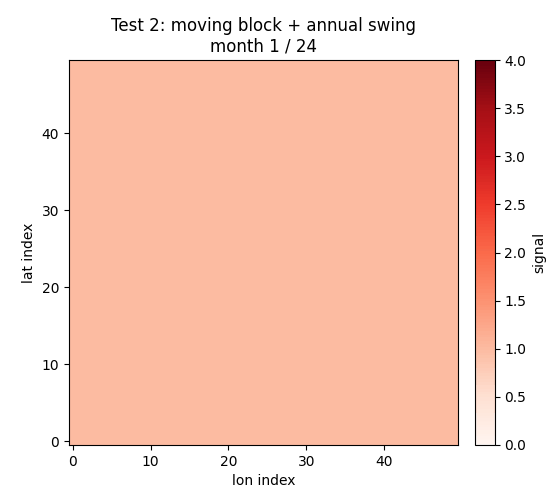

In [23]:
# ---- animate Test 2 (reuses animate_field from Section B) -------------------
# single-hue sequential colormap: the feature of interest is 0 -> high, so use
# 'viridis' and clamp the low end to 0 (the uniform swing dips to -2, but we
# want the block/positive concentration to read on a single-color scale).
out2 = animate_field(da2, 'Test 2: moving block + annual swing',
                     'synthetic_moving_block.gif', vmin=0, cmap='Reds')
print('Test 2 animation:'); display(Image(filename=out2))

In [24]:
# ---- decompose Test 2 with the same harmonic function ----------------------
print('=== Test 2: moving block + annual swing ===')
M2, coef2, amp2, pha2 = harmonic_decompose(da2)

=== Test 2: moving block + annual swing ===
  12: amp 8.293e-01 - 1.928e+00, pha 70.48 - 98.48 deg
   6: amp 3.377e-16 - 6.667e-01, pha 60.00 - 240.00 deg
   4: amp 1.111e-01 - 5.556e-01, pha 90.00 - 341.57 deg


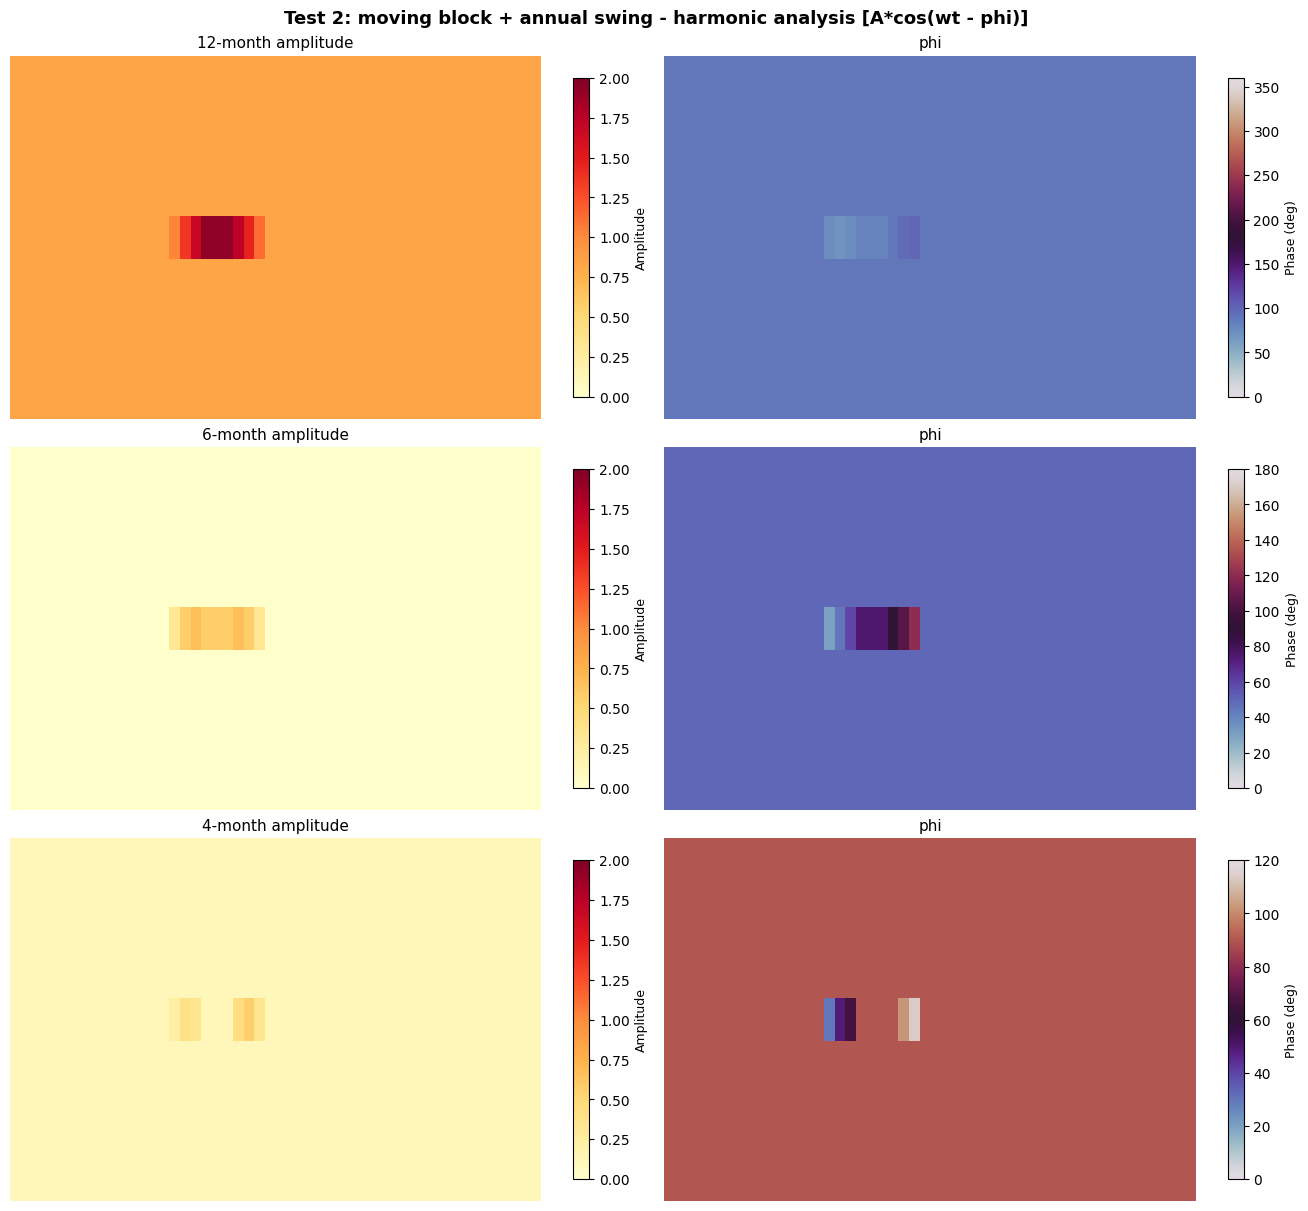

saved -> ../Figures/test_harmonics_moving_block.png


In [25]:
# ---- amplitude / phase maps for Test 2 (reuses plot_harmonics) -------------
plot_harmonics(amp2, pha2,
               'Test 2: moving block + annual swing - harmonic analysis [A*cos(wt - phi)]',
               'test_harmonics_moving_block.png')